#  Amazon Product Recommendation System
## Deep Learning · NLP · Embeddings · Cosine Similarity

---

> **Objectif :** Construire un moteur de recommandation intelligent à partir de titres et features produits Amazon, en combinant TF-IDF, Cosine Similarity, et un réseau de neurones avec Embedding Layers.

### Pipeline du projet
```
Dataset CSV
   │
   ▼
Data Cleaning & Feature Engineering
   │
   ▼
Exploratory Data Analysis (EDA)
   │
   ▼
NLP → TF-IDF Vectorization → Cosine Similarity (Baseline)
   │
   ▼
Deep Learning Model (Embeddings + Dense Layers)
   │
   ▼
Système Final de Recommandation
   │
   ▼
Dashboard Interactif (Plotly)
```

---
##  ÉTAPE 1 — Importation des Bibliothèques

On importe tout ce dont on aura besoin : manipulation de données, visualisation, NLP, et Deep Learning.

In [3]:
# ─── Data Manipulation ───────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import re
import warnings
warnings.filterwarnings('ignore')

# ─── Visualisation ────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# ─── NLP ──────────────────────────────────────────────────────────────────────
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error

# ─── Deep Learning ────────────────────────────────────────────────────────────
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.layers import (
    Input, Embedding, Flatten, Dense, Dropout,
    Concatenate, BatchNormalization
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# ─── Dimensionality Reduction (pour visualisation embeddings) ─────────────────
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

print(f' TensorFlow version : {tf.__version__}')
print(f' Pandas version     : {pd.__version__}')
print('Toutes les bibliothèques importées avec succès.')

# ─── Style global des graphiques ──────────────────────────────────────────────
sns.set_style('whitegrid')
plt.rcParams.update({'figure.figsize': (10, 5), 'axes.titlesize': 14})
PALETTE = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FFEAA7', '#DDA0DD']
np.random.seed(42)
tf.random.set_seed(42)

2026-05-02 11:05:32.130639: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777719932.415953      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777719932.501884      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777719933.167755      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777719933.167831      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777719933.167835      57 computation_placer.cc:177] computation placer alr

 TensorFlow version : 2.19.0
 Pandas version     : 2.3.3
Toutes les bibliothèques importées avec succès.


---
##  ÉTAPE 2 — Chargement du Dataset

On charge le CSV et on explore sa structure : dimensions, types de colonnes, statistiques descriptives.

In [11]:
import pandas as pd
import kagglehub
import os

# Télécharger le dataset
path = kagglehub.dataset_download(
    "ikramshah512/amazon-products-sales-dataset-42k-items-2025"
)

print("Dataset téléchargé dans :", path)

# Voir les fichiers disponibles
print(os.listdir(path))

Dataset téléchargé dans : /kaggle/input/datasets/ikramshah512/amazon-products-sales-dataset-42k-items-2025
['amazon_products_sales_data_cleaned.csv', 'amazon_products_sales_data_uncleaned.csv']


In [13]:
df = pd.read_csv(f"{path}/amazon_products_sales_data_cleaned.csv")

---
##  ÉTAPE 3 — Data Cleaning

**Pourquoi ?** Des données brutes contiennent souvent des valeurs manquantes, des doublons, des types incorrects. Un modèle entraîné sur des données sales donnera de mauvais résultats.

Actions :
- Renommer les colonnes pour uniformiser
- Supprimer les doublons
- Gérer les valeurs nulles
- Convertir les prix en numérique
- Nettoyer le texte des titres

In [15]:
# ─── 3.1 Renommage des colonnes ───────────────────────────────────────────────
# Mapping des noms de colonnes originales → noms standardisés
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')

COLUMN_MAP = {
    'title'                    : 'product_title',
    'rating'                   : 'product_rating',
    'number_of_reviews'        : 'total_reviews',
    'bought_in_last_month'     : 'purchased_last_month',
    'current/discounted_price' : 'discounted_price',
    'price_on_variant'         : 'variant_price',
    'listed_price'             : 'original_price',
    'is_best_seller'           : 'is_best_seller',
    'is_sponsored'             : 'is_sponsored',
    'is_couponed'              : 'has_coupon',
}
df.rename(columns=COLUMN_MAP, inplace=True)

print(f'Colonnes après renommage : {list(df.columns)}')

# ─── 3.2 Suppression des doublons ────────────────────────────────────────────
before = len(df)
df.drop_duplicates(subset=['product_title'], inplace=True)
print(f'\n  Doublons supprimés : {before - len(df)} (reste {len(df):,} produits)')

# ─── 3.3 Suppression des lignes sans titre ───────────────────────────────────
df.dropna(subset=['product_title'], inplace=True)

# ─── 3.4 Fonction de nettoyage prix ──────────────────────────────────────────
def clean_price(val):
    """Convertit une chaîne de prix (ex: '$12.99', '12,99') en float."""
    if pd.isna(val):
        return np.nan
    cleaned = re.sub(r'[^\d.]', '', str(val).replace(',', '.'))
    try:
        return float(cleaned)
    except ValueError:
        return np.nan

for col in ['discounted_price', 'original_price', 'variant_price']:
    if col in df.columns:
        df[col] = df[col].apply(clean_price)

# ─── 3.5 Nettoyage du rating ─────────────────────────────────────────────────
df['product_rating'] = pd.to_numeric(df['product_rating'], errors='coerce')
df['total_reviews']  = pd.to_numeric(df['total_reviews'].astype(str)
                                       .str.replace(',', ''), errors='coerce')
df['purchased_last_month'] = pd.to_numeric(
    df['purchased_last_month'].astype(str).str.replace(',', ''), errors='coerce')

# ─── 3.6 Remplissage des NaN numériques ──────────────────────────────────────
num_cols = ['product_rating', 'total_reviews', 'purchased_last_month',
            'discounted_price', 'original_price']
for col in num_cols:
    if col in df.columns:
        df[col].fillna(df[col].median(), inplace=True)

# ─── 3.7 Encodage des colonnes booléennes ────────────────────────────────────
bool_cols = ['is_best_seller', 'is_sponsored', 'has_coupon']
for col in bool_cols:
    if col in df.columns:
        df[col] = df[col].astype(str).str.lower()
        df[col] = df[col].map({'true': 1, 'false': 0, '1': 1, '0': 0,
                                'yes': 1, 'no': 0}).fillna(0).astype(int)

# ─── 3.8 Nettoyage du texte titre ────────────────────────────────────────────
def clean_text(text):
    """Nettoyage léger : minuscules, suppression ponctuations superflues."""
    if pd.isna(text):
        return ''
    text = str(text).lower()
    text = re.sub(r'[^a-z0-9\s]', ' ', text)   # garde lettres, chiffres, espaces
    text = re.sub(r'\s+', ' ', text).strip()     # espaces multiples → un seul
    return text

df['clean_title'] = df['product_title'].apply(clean_text)

# ─── 3.9 Réinitialisation de l'index ─────────────────────────────────────────
df.reset_index(drop=True, inplace=True)

print(f'\n Dataset nettoyé : {df.shape[0]:,} produits × {df.shape[1]} colonnes')
display(df.head(3))

Colonnes après renommage : ['product_title', 'product_rating', 'total_reviews', 'purchased_last_month', 'discounted_price', 'original_price', 'is_best_seller', 'is_sponsored', 'has_coupon', 'buy_box_availability', 'delivery_date', 'sustainability_tags', 'product_image_url', 'product_page_url', 'data_collected_at', 'product_category', 'discount_percentage']

  Doublons supprimés : 33867 (reste 8,808 produits)

 Dataset nettoyé : 8,808 produits × 18 colonnes


,product_title,product_rating,total_reviews,purchased_last_month,discounted_price,original_price,is_best_seller,is_sponsored,has_coupon,buy_box_availability,delivery_date,sustainability_tags,product_image_url,product_page_url,data_collected_at,product_category,discount_percentage,clean_title
0,BOYA BOYALINK 2 Wireless Lavalier Microphone f...,4.6,375.0,300.0,89.68,159.00,0,0,0,Add to cart,2025-09-01,Carbon impact,https://m.media-amazon.com/images/I/71pAqiVEs3...,https://www.amazon.com/sspa/click?ie=UTF8&spc=...,2025-08-21 11:14:29,Phones,43.60,boya boyalink 2 wireless lavalier microphone f...
1,"LISEN USB C to Lightning Cable, 240W 4 in 1 Ch...",4.3,2457.0,6000.0,9.99,15.99,0,0,0,Add to cart,2025-08-29,NaN,https://m.media-amazon.com/images/I/61nbF6aVIP...,https://www.amazon.com/sspa/click?ie=UTF8&spc=...,2025-08-21 11:14:29,Laptops,37.52,lisen usb c to lightning cable 240w 4 in 1 cha...
2,"DJI Mic 2 (2 TX + 1 RX + Charging Case), Wirel...",4.6,3044.0,2000.0,314.00,349.00,0,0,0,Add to cart,2025-09-01,NaN,https://m.media-amazon.com/images/I/61h78MEXoj...,https://www.amazon.com/sspa/click?ie=UTF8&spc=...,2025-08-21 11:14:29,Laptops,10.03,dji mic 2 2 tx 1 rx charging case wireless lav...


---
##  ÉTAPE 4 — Feature Engineering

**Pourquoi ?** Les modèles ML/DL nécessitent des features numériques bien construites. On crée :
- `discount_percentage` : réduction en %
- `popularity_score` : score composite (reviews × acheteurs × rating)
- Features normalisées pour le modèle DL

In [17]:
# ─── 4.1 Pourcentage de réduction ────────────────────────────────────────────
df['discount_percentage'] = np.where(
    df['original_price'] > 0,
    ((df['original_price'] - df['discounted_price']) / df['original_price'] * 100).clip(0, 100),
    0
).round(2)

# ─── 4.2 Score de popularité ─────────────────────────────────────────────────
# Formule : log(1 + reviews) × log(1 + purchased) × rating
df['popularity_score'] = (
    np.log1p(df['total_reviews']) *
    np.log1p(df['purchased_last_month']) *
    df['product_rating']
).round(4)

# ─── 4.3 Indicateur prix bas ──────────────────────────────────────────────────
df['is_budget'] = (df['discounted_price'] < df['discounted_price'].median()).astype(int)

# ─── 4.4 Normalisation des features numériques ───────────────────────────────
scaler = MinMaxScaler()
FEATURES_TO_SCALE = [
    'product_rating', 'total_reviews', 'purchased_last_month',
    'discounted_price', 'discount_percentage', 'popularity_score'
]

df_scaled = df.copy()
df_scaled[FEATURES_TO_SCALE] = scaler.fit_transform(df[FEATURES_TO_SCALE])

print(' Feature Engineering terminé.')
print(f'Nouvelles colonnes : discount_percentage, popularity_score, is_budget')
display(df[['product_title', 'discounted_price', 'original_price',
            'discount_percentage', 'popularity_score', 'is_best_seller']].head(5))

 Feature Engineering terminé.
Nouvelles colonnes : discount_percentage, popularity_score, is_budget


,product_title,discounted_price,original_price,discount_percentage,popularity_score,is_best_seller
0,BOYA BOYALINK 2 Wireless Lavalier Microphone f...,89.68,159.00,43.60,155.6678,0
1,"LISEN USB C to Lightning Cable, 240W 4 in 1 Ch...",9.99,15.99,37.52,292.0530,0
2,"DJI Mic 2 (2 TX + 1 RX + Charging Case), Wirel...",314.00,349.00,10.03,280.4749,0
3,"Apple AirPods Pro 2 Wireless Earbuds, Active N...",162.24,162.24,0.00,444.3567,0
4,Apple AirTag 4 Pack. Keep Track of and find Yo...,72.74,72.74,0.00,454.2444,0


---
##  ÉTAPE 5 — Exploratory Data Analysis (EDA)

On explore le dataset visuellement pour comprendre les distributions, les tendances et les corrélations.

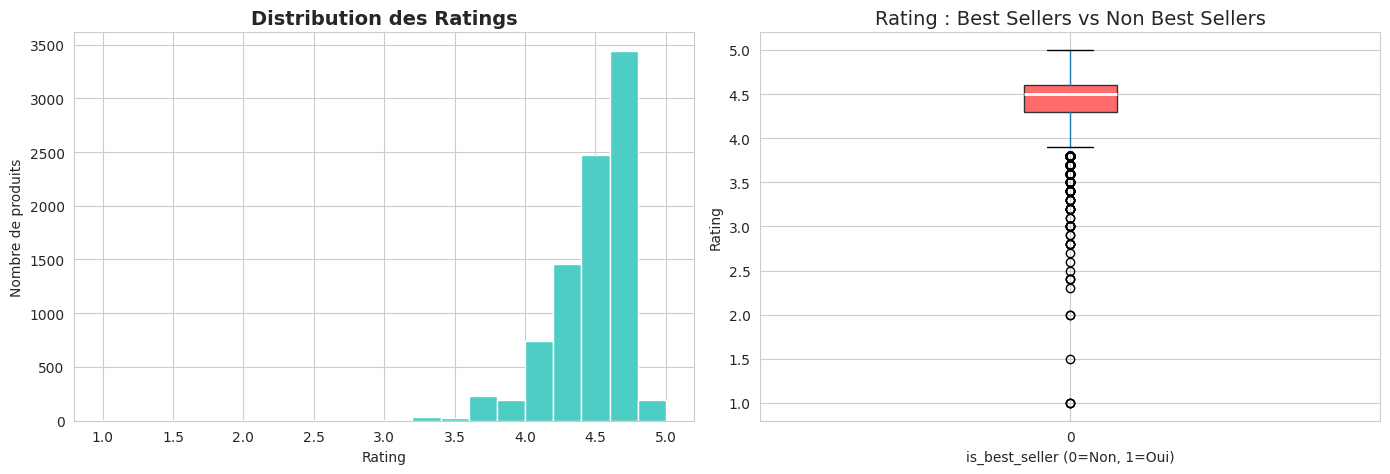

 Les best sellers ont tendance à avoir des ratings légèrement plus élevés.


In [18]:
# ─── 5.1 Distribution des Ratings ────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['product_rating'].dropna(), bins=20, color='#4ECDC4', edgecolor='white')
axes[0].set_title('Distribution des Ratings', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Rating')
axes[0].set_ylabel('Nombre de produits')

# Boxplot par catégorie best seller
df.boxplot(column='product_rating', by='is_best_seller', ax=axes[1],
           patch_artist=True,
           boxprops=dict(facecolor='#FF6B6B', color='#333'),
           medianprops=dict(color='white', linewidth=2))
axes[1].set_title('Rating : Best Sellers vs Non Best Sellers')
axes[1].set_xlabel('is_best_seller (0=Non, 1=Oui)')
axes[1].set_ylabel('Rating')
plt.suptitle('')
plt.tight_layout()
plt.show()
print(' Les best sellers ont tendance à avoir des ratings légèrement plus élevés.')

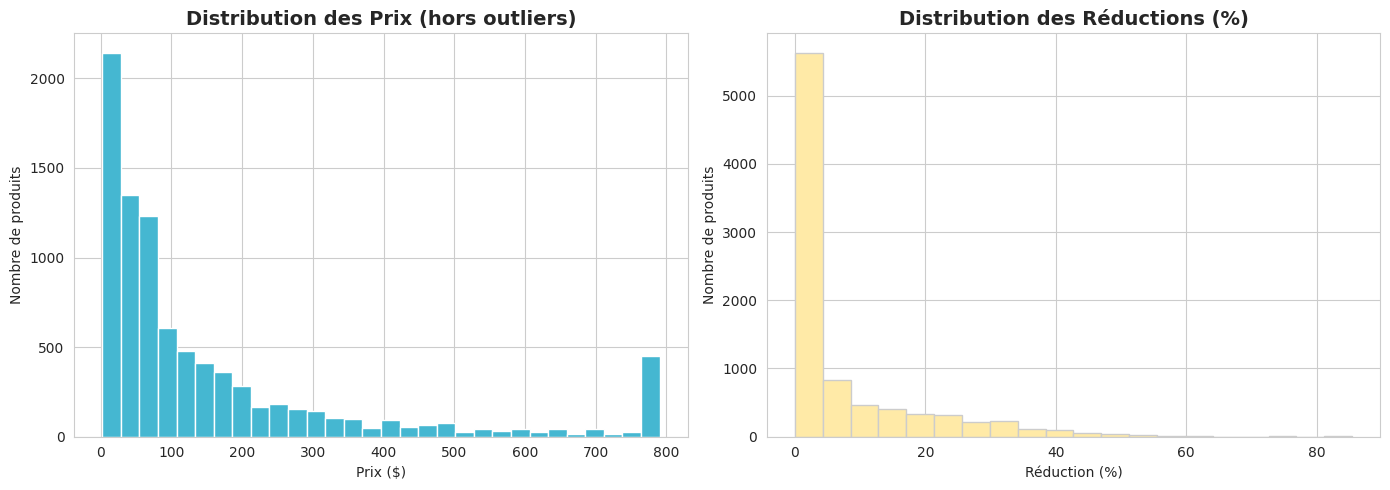

 La majorité des produits sont sous les 100$. Beaucoup ont 0% de réduction.


In [19]:
# ─── 5.2 Distribution des Prix ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Supprime les outliers extrêmes pour la visualisation
price_data = df['discounted_price'].clip(upper=df['discounted_price'].quantile(0.95))

axes[0].hist(price_data, bins=30, color='#45B7D1', edgecolor='white')
axes[0].set_title('Distribution des Prix (hors outliers)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Prix ($)')
axes[0].set_ylabel('Nombre de produits')

axes[1].hist(df['discount_percentage'], bins=20, color='#FFEAA7', edgecolor='#ccc')
axes[1].set_title('Distribution des Réductions (%)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Réduction (%)')
axes[1].set_ylabel('Nombre de produits')

plt.tight_layout()
plt.show()
print(' La majorité des produits sont sous les 100$. Beaucoup ont 0% de réduction.')

In [20]:
# ─── 5.3 Top 15 produits les plus populaires ────────────────────────────────
top15 = df.nlargest(15, 'popularity_score')[['product_title', 'popularity_score',
                                              'product_rating', 'total_reviews']]
top15['short_title'] = top15['product_title'].str[:40] + '...'

fig = px.bar(
    top15.sort_values('popularity_score'),
    x='popularity_score',
    y='short_title',
    orientation='h',
    color='product_rating',
    color_continuous_scale='Teal',
    title=' Top 15 Produits par Score de Popularité',
    labels={'popularity_score': 'Score de Popularité', 'short_title': 'Produit'}
)
fig.update_layout(height=500, coloraxis_colorbar_title='Rating')
fig.show()
print(' Le score de popularité combine reviews, achats récents et rating.')

 Le score de popularité combine reviews, achats récents et rating.


ValueError: 'labels' must be of length 'x', not 2

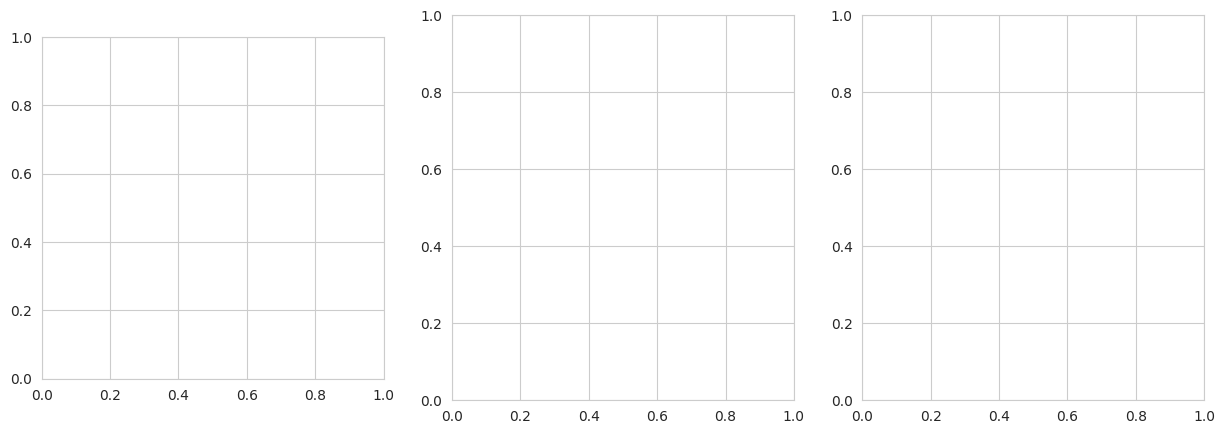

In [21]:
# ─── 5.4 Pie Charts : Best Sellers / Sponsored / Coupon ─────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, col, title, colors in zip(
    axes,
    ['is_best_seller', 'is_sponsored', 'has_coupon'],
    ['Best Sellers', 'Sponsored', 'Coupon'],
    [['#FF6B6B', '#4ECDC4'], ['#45B7D1', '#96CEB4'], ['#FFEAA7', '#DDA0DD']]
):
    counts = df[col].value_counts()
    ax.pie(counts, labels=['Non', 'Oui'], colors=colors,
           autopct='%1.1f%%', startangle=90,
           wedgeprops=dict(edgecolor='white', linewidth=2))
    ax.set_title(f'{title}', fontsize=13, fontweight='bold')

plt.suptitle('Répartition des caractéristiques produits', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

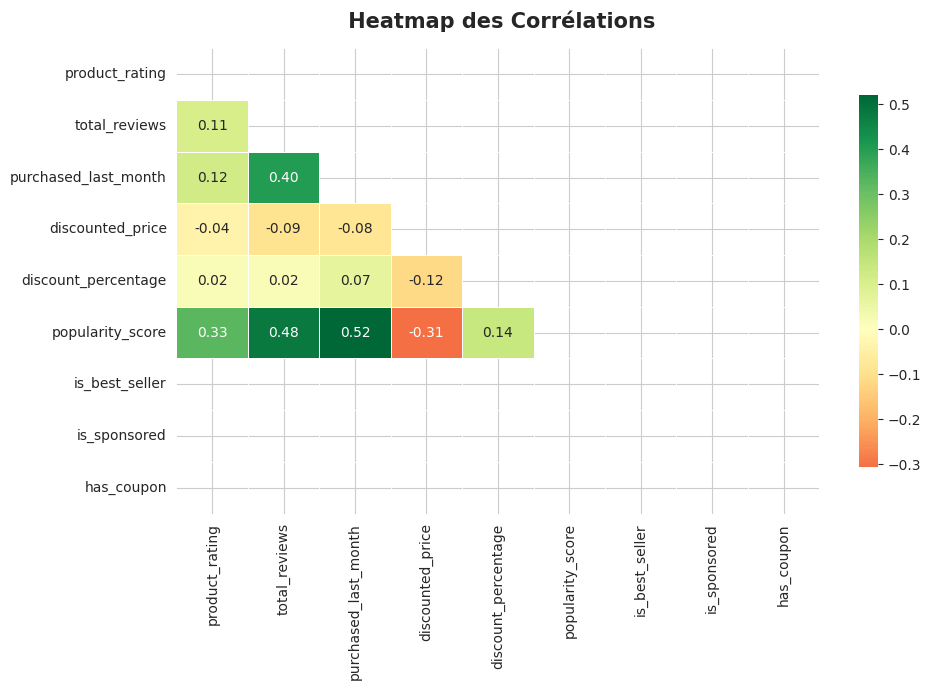

 Plus la couleur est verte, plus la corrélation est forte (positive).
   Rouge = corrélation négative. Blanc = absence de corrélation.


In [22]:
# ─── 5.5 Heatmap de corrélation ───────────────────────────────────────────────
corr_cols = ['product_rating', 'total_reviews', 'purchased_last_month',
             'discounted_price', 'discount_percentage', 'popularity_score',
             'is_best_seller', 'is_sponsored', 'has_coupon']

corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(10, 7))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, linewidths=0.5,
            cbar_kws={'shrink': 0.8})
plt.title(' Heatmap des Corrélations', fontsize=15, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()
print(' Plus la couleur est verte, plus la corrélation est forte (positive).')
print('   Rouge = corrélation négative. Blanc = absence de corrélation.')

In [ ]:
# ─── 5.6 Scatter interactif : Prix vs Rating vs Popularité ──────────────────
plot_df = df.copy()
plot_df['title_short'] = df['product_title'].str[:50]
plot_df['price_clipped'] = df['discounted_price'].clip(upper=df['discounted_price'].quantile(0.95))

fig = px.scatter(
    plot_df.sample(min(500, len(plot_df))),  # max 500 points pour lisibilité
    x='price_clipped',
    y='product_rating',
    size='popularity_score',
    color='is_best_seller',
    hover_name='title_short',
    color_discrete_map={0: '#4ECDC4', 1: '#FF6B6B'},
    title=' Prix vs Rating — taille = popularité | couleur = best seller',
    labels={'price_clipped': 'Prix ($)', 'product_rating': 'Rating',
            'is_best_seller': 'Best Seller'}
)
fig.update_layout(height=500)
fig.show()

---
##  ÉTAPE 6 — NLP & TF-IDF Embeddings

### Pourquoi transformer du texte en vecteurs ?

Les algorithmes ne comprennent pas les mots, seulement les nombres. **TF-IDF** (Term Frequency–Inverse Document Frequency) transforme chaque titre en vecteur numérique :

- **TF** : combien de fois un mot apparaît dans un produit
- **IDF** : log(N / (1 + df)) — pondère les mots rares plus fortement que les mots communs

Résultat : chaque produit devient un point dans un espace vectoriel à N dimensions.

In [24]:
# ─── 6.1 Vectorisation TF-IDF ────────────────────────────────────────────────
tfidf = TfidfVectorizer(
    max_features=5000,      # vocabulaire limité aux 5000 mots les plus importants
    ngram_range=(1, 2),     # unigrammes + bigrammes
    stop_words='english',   # supprime les mots vides (the, a, is...)
    min_df=2,               # ignore les mots qui apparaissent dans < 2 documents
    sublinear_tf=True       # applique log au TF pour lisser les fréquences élevées
)

tfidf_matrix = tfidf.fit_transform(df['clean_title'])

print(f' Matrice TF-IDF construite : {tfidf_matrix.shape}')
print(f'   → {tfidf_matrix.shape[0]:,} produits × {tfidf_matrix.shape[1]:,} termes')
print(f'   → Densité : {tfidf_matrix.nnz / (tfidf_matrix.shape[0] * tfidf_matrix.shape[1]) * 100:.3f}%')

# Top mots du vocabulaire
vocab = tfidf.get_feature_names_out()
print(f'\n Exemple de termes dans le vocabulaire : {list(vocab[:20])}')

 Matrice TF-IDF construite : (8808, 5000)
   → 8,808 produits × 5,000 termes
   → Densité : 0.400%

 Exemple de termes dans le vocabulaire : ['00', '000', '000 dpi', '000 insurance', '000 pages', '000 sq', '01', '010', '032g', '03ms', '10', '10 11', '10 5k', '10 core', '10 ft', '10 gbps', '10 inch', '10 pack', '10 pro', '10 sheets']


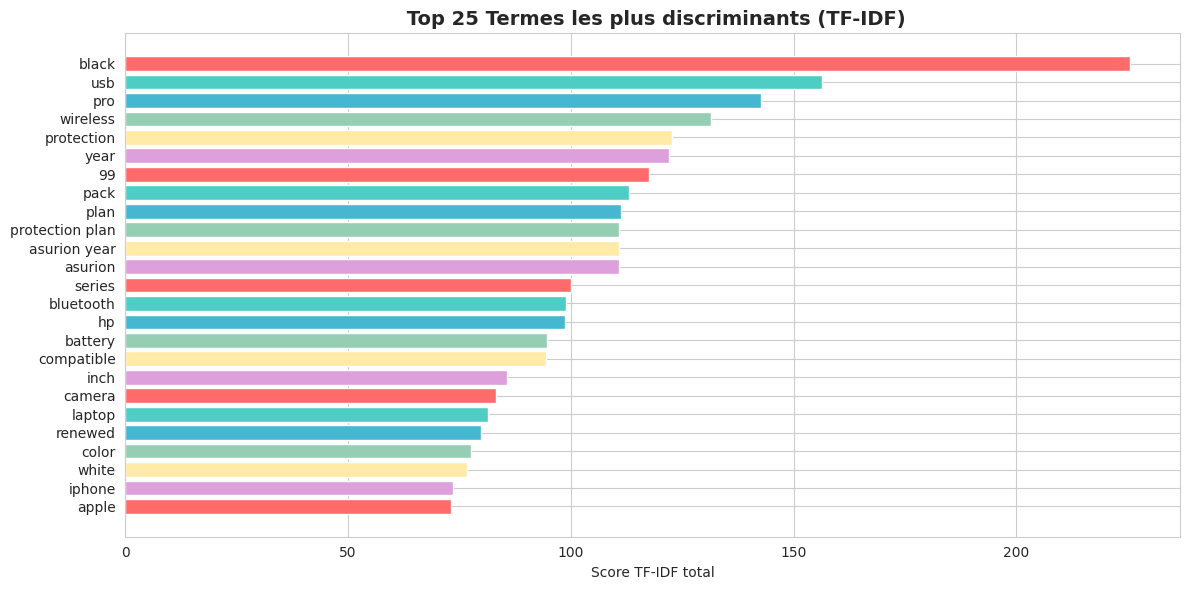

 Ces termes sont les plus informatifs pour distinguer les produits entre eux.


In [25]:
# ─── 6.2 Visualisation des mots les plus fréquents ───────────────────────────
# Somme des scores TF-IDF par terme
word_scores = np.array(tfidf_matrix.sum(axis=0)).flatten()
top_words_idx = word_scores.argsort()[-25:][::-1]
top_words     = [(vocab[i], word_scores[i]) for i in top_words_idx]

words, scores = zip(*top_words)
fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(range(len(words)), scores, color=PALETTE * 5)
ax.set_yticks(range(len(words)))
ax.set_yticklabels(words, fontsize=10)
ax.invert_yaxis()
ax.set_xlabel('Score TF-IDF total')
ax.set_title(' Top 25 Termes les plus discriminants (TF-IDF)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
print(' Ces termes sont les plus informatifs pour distinguer les produits entre eux.')


 COSINE SIMILARITY — Comment ça marche ?
════════════════════════════════════════════

Deux produits A et B sont représentés par des vecteurs dans un espace à N dimensions.

  cos(θ) = (A · B) / (||A|| × ||B||)

  • cos = 1  → produits identiques (même direction)
  • cos = 0  → produits sans rapport (vecteurs orthogonaux)
  • cos = -1 → produits opposés (rare en NLP car TF-IDF ≥ 0)

On utilise la cosine PLUTÔT que la distance euclidienne car elle est
insensible à la longueur des vecteurs (un titre court vs long).

 Matrice de similarité (sample) : (2000, 2000)


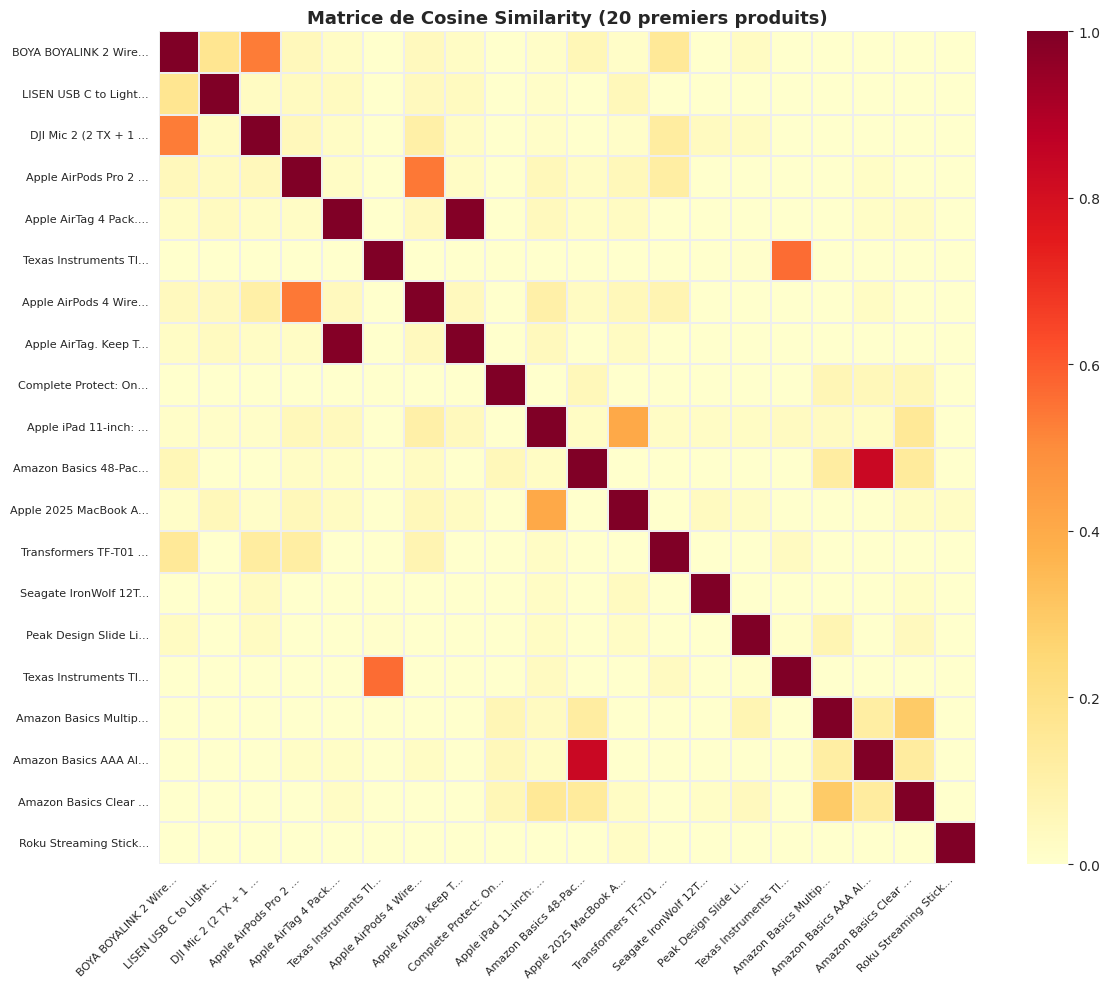

 Plus la couleur est rouge, plus deux produits sont similaires (similitude proche de 1).


In [26]:
# ─── 6.3 Cosine Similarity — Explication ─────────────────────────────────────
print('''
 COSINE SIMILARITY — Comment ça marche ?
════════════════════════════════════════════

Deux produits A et B sont représentés par des vecteurs dans un espace à N dimensions.

  cos(θ) = (A · B) / (||A|| × ||B||)

  • cos = 1  → produits identiques (même direction)
  • cos = 0  → produits sans rapport (vecteurs orthogonaux)
  • cos = -1 → produits opposés (rare en NLP car TF-IDF ≥ 0)

On utilise la cosine PLUTÔT que la distance euclidienne car elle est
insensible à la longueur des vecteurs (un titre court vs long).
''')

# ─── 6.4 Matrice de similarité (échantillon pour la mémoire) ─────────────────
# Pour de grands datasets, on calcule la similarité à la volée (voir étape 7)
SAMPLE_SIZE = min(2000, len(df))
tfidf_sample = tfidf_matrix[:SAMPLE_SIZE]

cosine_sim_matrix = cosine_similarity(tfidf_sample, tfidf_sample)
print(f' Matrice de similarité (sample) : {cosine_sim_matrix.shape}')

# Heatmap sur un sous-échantillon de 20 produits
n_show = 20
labels_short = [t[:20] + '...' for t in df['product_title'].iloc[:n_show]]

plt.figure(figsize=(12, 10))
sns.heatmap(cosine_sim_matrix[:n_show, :n_show],
            xticklabels=labels_short, yticklabels=labels_short,
            cmap='YlOrRd', vmin=0, vmax=1,
            linewidths=0.3, linecolor='#eee')
plt.title('Matrice de Cosine Similarity (20 premiers produits)',
          fontsize=13, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.show()
print(' Plus la couleur est rouge, plus deux produits sont similaires (similitude proche de 1).')

---
##  ÉTAPE 7 — Système Baseline : Recommandation par Cosine Similarity

Premier moteur de recommandation, simple et interprétable.

In [27]:
# ─── 7.1 Index inverse titre → idx ───────────────────────────────────────────
# Créé un dictionnaire titre → indice pour retrouver rapidement un produit
title_to_idx = pd.Series(df.index, index=df['product_title']).to_dict()

# ─── 7.2 Fonction de recommandation baseline ─────────────────────────────────
def recommend_baseline(product_name: str, top_n: int = 5) -> pd.DataFrame:
    """
    Recommande les top_n produits les plus similaires via TF-IDF + Cosine Similarity.

    Args:
        product_name : titre exact ou partiel du produit
        top_n        : nombre de recommandations

    Returns:
        DataFrame avec les produits recommandés et leur score de similarité
    """
    # Recherche approximative du produit dans l'index
    matches = [t for t in title_to_idx if product_name.lower() in t.lower()]
    if not matches:
        print(f' Produit "{product_name}" non trouvé. Essaie un autre mot-clé.')
        return pd.DataFrame()

    # Prend le premier match
    product_title = matches[0]
    idx = title_to_idx[product_title]

    # Calcul de la similarité entre ce produit et TOUS les autres (à la volée)
    product_vec   = tfidf_matrix[idx]                                # vecteur du produit
    sim_scores    = cosine_similarity(product_vec, tfidf_matrix).flatten()

    # Tri décroissant, on exclut le produit lui-même (sim=1.0)
    similar_idx   = np.argsort(sim_scores)[::-1][1:top_n + 1]
    similar_scores = sim_scores[similar_idx]

    results = df.iloc[similar_idx][['product_title', 'product_rating',
                                    'discounted_price', 'popularity_score',
                                    'is_best_seller']].copy()
    results['similarity_score'] = similar_scores.round(4)
    results.reset_index(drop=True, inplace=True)

    print(f'\n Produit de référence : "{product_title}"')
    print(f' Top {top_n} recommandations (Baseline TF-IDF)\n')
    return results


# ─── 7.3 Test du système baseline ────────────────────────────────────────────
# Remplace par un mot-clé présent dans ton dataset
sample_keyword = df['product_title'].iloc[0].split()[:3]  # 3 premiers mots du 1er produit
sample_query   = ' '.join(sample_keyword)

recs_baseline = recommend_baseline(sample_query, top_n=5)
display(recs_baseline)


 Produit de référence : "BOYA BOYALINK 2 Wireless Lavalier Microphone for iPhone Camera Android, Mini Lapel Micophone Wireless, 48 KHz 24 Bit, 6mm Mic, 1000ft, 30h Use, Noise Cancelling, Clip on Mic USB-C/Lightning/3.5mm TRS"
 Top 5 recommandations (Baseline TF-IDF)



,product_title,product_rating,discounted_price,popularity_score,is_best_seller,similarity_score
0,BOYALINK 2 Wireless Lavalier Microphone for iP...,4.5,99.00,112.5950,0,0.6164
1,"DJI Mic Mini (2 TX + 1 RX + Charging Case), Wi...",4.7,139.50,365.6343,0,0.5709
2,"DJI Mic 2 (2 TX + 1 RX + Charging Case), Wirel...",4.6,314.00,280.4749,0,0.5322
3,NEEWER CM28 Wireless Lavalier Microphone Syste...,4.6,109.99,204.4842,0,0.4220
4,BOYA BY-V4U Wireless Lavalier Microphone for i...,4.3,139.99,125.5447,0,0.4105


---
##  ÉTAPE 8 — Deep Learning : Pourquoi et Comment ?

### Pourquoi pas CNN ou RNN ici ?

| Modèle | Usage typique | Adapté ici ? |
|--------|---------------|--------------|
| CNN    | Images, séquences courtes |  Nos titres ne sont pas des images |
| RNN/LSTM | Séquences longues ordonnées |  Trop lourd pour des titres courts |
| **Embedding + Dense** | Données tabulaires + ID items |  Parfait pour notre cas |

### Architecture choisie

On encode chaque produit par un **ID numérique** → une **Embedding Layer** apprend une représentation dense → des **Dense Layers** apprennent à prédire si deux produits sont similaires.

In [28]:
# ─── 8.1 Préparation des données pour le modèle DL ───────────────────────────

# Chaque produit reçoit un ID entier unique
df['product_id'] = df.index
N_PRODUCTS       = len(df)
EMBED_DIM        = 32     # dimension de l'espace d'embedding

# Features numériques normalisées
FEATURE_COLS = ['product_rating', 'total_reviews', 'purchased_last_month',
                'discounted_price', 'discount_percentage',
                'is_best_seller', 'is_sponsored', 'has_coupon']

X_features = df_scaled[FEATURE_COLS].fillna(0).values.astype('float32')

# ─── 8.2 Génération de paires produits (apprentissage supervisé) ──────────────
# On crée des paires (produit_A, produit_B) avec label = leur cosine similarity
# → le modèle apprend à prédire la similarité à partir des features

print(' Génération des paires d\'entraînement...')

N_PAIRS  = min(30_000, N_PRODUCTS * 10)  # limite pour la mémoire
idx_a    = np.random.randint(0, N_PRODUCTS, N_PAIRS)
idx_b    = np.random.randint(0, N_PRODUCTS, N_PAIRS)

# Calcul de la cosine similarity TF-IDF comme label cible
labels = np.array([
    cosine_similarity(tfidf_matrix[a], tfidf_matrix[b]).flatten()[0]
    for a, b in zip(idx_a, idx_b)
], dtype='float32')

print(f' {N_PAIRS:,} paires générées.')
print(f'   Distribution des labels : min={labels.min():.3f} | mean={labels.mean():.3f} | max={labels.max():.3f}')

# ─── 8.3 Train / Test split ───────────────────────────────────────────────────
(idx_a_train, idx_a_test,
 idx_b_train, idx_b_test,
 y_train,     y_test) = train_test_split(
    idx_a, idx_b, labels,
    test_size=0.2, random_state=42
)

feat_a_train = X_features[idx_a_train]
feat_b_train = X_features[idx_b_train]
feat_a_test  = X_features[idx_a_test]
feat_b_test  = X_features[idx_b_test]

print(f'\nTrain : {len(y_train):,} paires | Test : {len(y_test):,} paires')

 Génération des paires d'entraînement...
 30,000 paires générées.
   Distribution des labels : min=0.000 | mean=0.012 | max=1.000

Train : 24,000 paires | Test : 6,000 paires


---
##  ÉTAPE 9 — Architecture du Modèle Deep Learning

In [29]:
# ─── 9.1 Construction du modèle ──────────────────────────────────────────────
def build_recommendation_model(n_products: int, embed_dim: int, n_features: int) -> Model:
    """
    Architecture :
      [product_id_A]   → Embedding → Flatten ─┐
                                               ├─ Concatenate → Dense → Dropout → Dense → Output
      [product_id_B]   → Embedding → Flatten ─┘
      [features_A, features_B] ────────────────┘
    """
    # ── Entrées ──────────────────────────────────────────────────────────────
    input_id_a   = Input(shape=(1,),          name='product_id_A')
    input_id_b   = Input(shape=(1,),          name='product_id_B')
    input_feat_a = Input(shape=(n_features,), name='features_A')
    input_feat_b = Input(shape=(n_features,), name='features_B')

    # ── Embedding Layer partagée ──────────────────────────────────────────────
    # Pourquoi partagée ? Les deux produits vivent dans le même espace vectoriel
    embedding_layer = Embedding(
        input_dim=n_products + 1,
        output_dim=embed_dim,
        embeddings_initializer='he_normal',
        name='product_embeddings'
    )

    embed_a = Flatten()(embedding_layer(input_id_a))   # (batch, embed_dim)
    embed_b = Flatten()(embedding_layer(input_id_b))

    # ── Fusion : embeddings + features numériques ─────────────────────────────
    merged = Concatenate()([embed_a, embed_b, input_feat_a, input_feat_b])

    # ── Dense Layers ─────────────────────────────────────────────────────────
    # ReLU : activation non-linéaire → permet au réseau d'apprendre des relations complexes
    x = Dense(256, activation='relu', name='dense_1')(merged)
    x = BatchNormalization(name='bn_1')(x)
    x = Dropout(0.3, name='dropout_1')(x)

    x = Dense(128, activation='relu', name='dense_2')(x)
    x = BatchNormalization(name='bn_2')(x)
    x = Dropout(0.2, name='dropout_2')(x)

    x = Dense(64, activation='relu', name='dense_3')(x)

    # ── Couche de sortie ──────────────────────────────────────────────────────
    # sigmoid → sortie entre 0 et 1 (comme la cosine similarity)
    output = Dense(1, activation='sigmoid', name='similarity_output')(x)

    model = Model(
        inputs=[input_id_a, input_id_b, input_feat_a, input_feat_b],
        outputs=output,
        name='DeepRecommender'
    )
    return model


# Instanciation
model = build_recommendation_model(
    n_products=N_PRODUCTS,
    embed_dim=EMBED_DIM,
    n_features=len(FEATURE_COLS)
)

model.summary()

print('''
 Explication des composants :
  • Embedding Layer  : apprend une représentation dense de chaque produit (comme Word2Vec)
  • Dense + ReLU     : apprend des combinaisons non-linéaires des features
  • BatchNorm        : stabilise l'entraînement (normalise les activations)
  • Dropout          : régularisation → évite l'overfitting
  • Adam Optimizer   : ajuste les poids en utilisant le gradient + momentum
  • MSE Loss         : minimise l'écart entre la similarité prédite et la vraie similarité
''')

2026-05-02 11:50:02.399714: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "DeepRecommender"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ product_id_A        │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ product_id_B        │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ product_embeddings  │ (None, 1, 32)     │    281,888 │ product_id_A[0][… │
│ (Embedding)         │                   │            │ product_id_B[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 32)        │          0 │ product_embeddin… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_1 (Flatten) │ (None, 32)        │          0 │ product_embeddin… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ features_A          │ (None, 8)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ features_B          │ (None, 8)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 80)        │          0 │ flatten[0][0],    │
│ (Concatenate)       │                   │            │ flatten_1[0][0],  │
│                     │                   │            │ features_A[0][0], │
│                     │                   │            │ features_B[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 256)       │     20,736 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_1                │ (None, 256)       │      1,024 │ dense_1[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 256)       │          0 │ bn_1[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 128)       │     32,896 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_2                │ (None, 128)       │        512 │ dense_2[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 128)       │          0 │ bn_2[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 64)        │      8,256 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ similarity_output   │ (None, 1)         │         65 │ dense_3[0][0]     │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 345,377 (1.32 MB)

 Trainable params: 344,609 (1.31 MB)

 Non-trainable params: 768 (3.00 KB)


 Explication des composants :
  • Embedding Layer  : apprend une représentation dense de chaque produit (comme Word2Vec)
  • Dense + ReLU     : apprend des combinaisons non-linéaires des features
  • BatchNorm        : stabilise l'entraînement (normalise les activations)
  • Dropout          : régularisation → évite l'overfitting
  • Adam Optimizer   : ajuste les poids en utilisant le gradient + momentum
  • MSE Loss         : minimise l'écart entre la similarité prédite et la vraie similarité



---
##  ÉTAPE 10 — Entraînement du Modèle

**Ce qui se passe pendant l'entraînement :**
1. **Forward pass** : le modèle prédit la similarité pour chaque paire
2. **Calcul de la Loss** : MSE entre prédiction et vraie similarité
3. **Backpropagation** : calcul du gradient de la loss par rapport à chaque poids
4. **Mise à jour des poids** : Adam utilise le gradient pour ajuster les poids (descente de gradient)

In [30]:
# ─── 10.1 Compilation ────────────────────────────────────────────────────────
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='mse',
    metrics=['mae']
)

# ─── 10.2 Callbacks ──────────────────────────────────────────────────────────
callbacks = [
    EarlyStopping(
        monitor='val_loss', patience=5,
        restore_best_weights=True, verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss', factor=0.5,
        patience=3, min_lr=1e-6, verbose=1
    )
]

# ─── 10.3 Entraînement ───────────────────────────────────────────────────────
history = model.fit(
    x=[idx_a_train, idx_b_train, feat_a_train, feat_b_train],
    y=y_train,
    validation_data=([idx_a_test, idx_b_test, feat_a_test, feat_b_test], y_test),
    epochs=30,
    batch_size=512,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/30
47/47 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step - loss: 0.0460 - mae: 0.1445 - val_loss: 0.0799 - val_mae: 0.2811 - learning_rate: 0.0010
Epoch 2/30
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0019 - mae: 0.0197 - val_loss: 0.0229 - val_mae: 0.1490 - learning_rate: 0.0010
Epoch 3/30
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0019 - mae: 0.0181 - val_loss: 0.0069 - val_mae: 0.0781 - learning_rate: 0.0010
Epoch 4/30
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0018 - mae: 0.0175 - val_loss: 0.0030 - val_mae: 0.0455 - learning_rate: 0.0010
Epoch 5/30
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0018 - mae: 0.0171 - val_loss: 0.0020 - val_mae: 0.0310 - learning_rate: 0.0010
Epoch 6/30
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0018 - mae: 0.0169 - val_loss: 0.0017 - val_mae: 0.0251 - learning_rate: 0.0010
Epoch 7/30
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0017 - mae: 0.0169 - val_loss: 0.0016 - val_mae: 0.0214 - learning_rate: 0.0010
Epoch 8/30
47

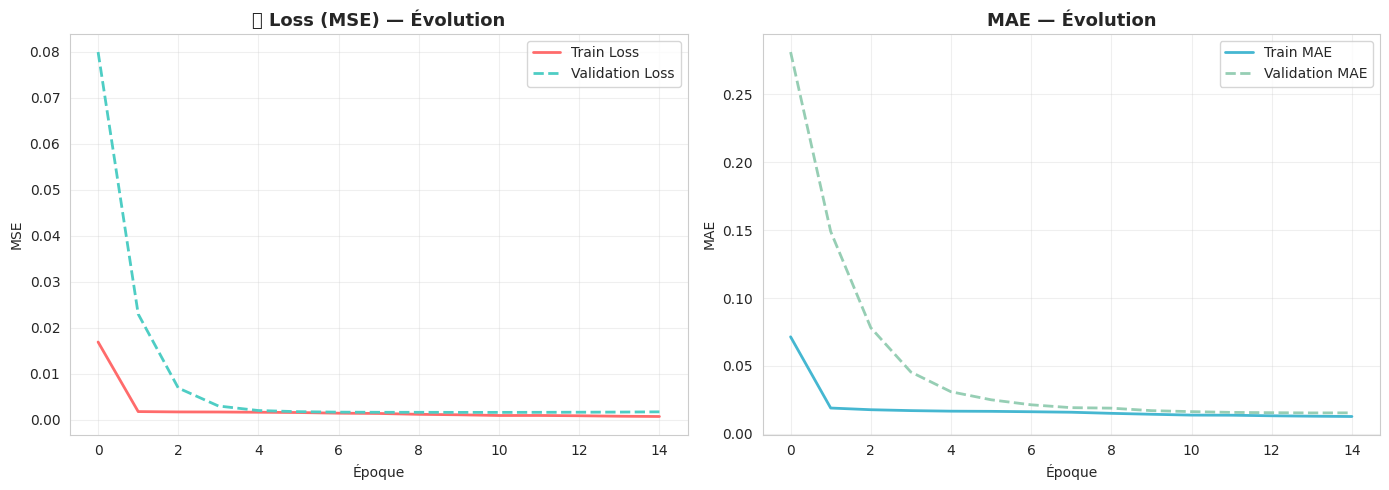


 Meilleur MAE  (validation) : 0.0154
   Meilleur MSE  (validation) : 0.001568


In [32]:
# ─── 10.4 Visualisation des courbes d'apprentissage ──────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['loss'],     label='Train Loss',      color='#FF6B6B', lw=2)
axes[0].plot(history.history['val_loss'], label='Validation Loss', color='#4ECDC4', lw=2, linestyle='--')
axes[0].set_title('📉 Loss (MSE) — Évolution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Époque')
axes[0].set_ylabel('MSE')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(history.history['mae'],     label='Train MAE',      color='#45B7D1', lw=2)
axes[1].plot(history.history['val_mae'], label='Validation MAE', color='#96CEB4', lw=2, linestyle='--')
axes[1].set_title('MAE — Évolution', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Époque')
axes[1].set_ylabel('MAE')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

final_val_mae = min(history.history['val_mae'])
final_val_mse = min(history.history['val_loss'])
print(f'\n Meilleur MAE  (validation) : {final_val_mae:.4f}')
print(f'   Meilleur MSE  (validation) : {final_val_mse:.6f}')

---
##  ÉTAPE 11 — Évaluation et Comparaison

On compare le modèle Deep Learning avec le baseline TF-IDF.


📊 Comparaison des modèles :


,Modèle,MAE,MSE,RMSE
0,Baseline (Moyenne naïve),0.01717,0.00153,0.03916
1,Deep Learning (Embeddings),0.01708,0.00157,0.03960


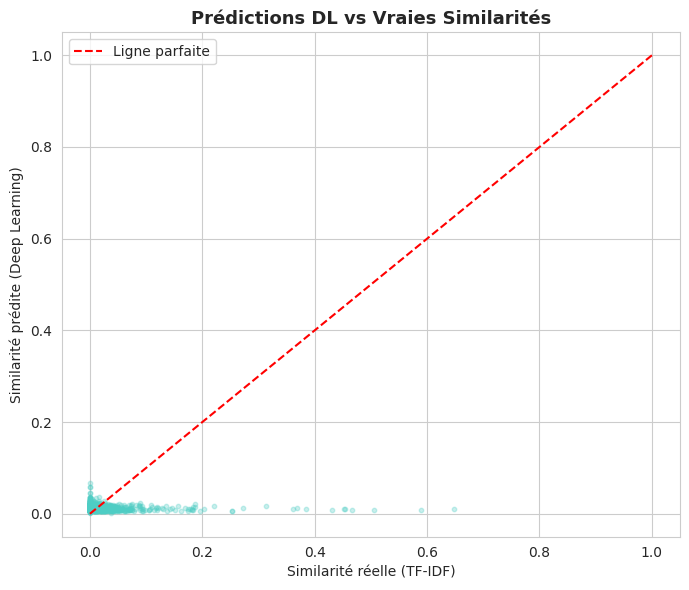

In [33]:
# ─── 11.1 Évaluation du modèle DL ────────────────────────────────────────────
y_pred_dl = model.predict(
    [idx_a_test, idx_b_test, feat_a_test, feat_b_test],
    verbose=0
).flatten()

mae_dl  = mean_absolute_error(y_test, y_pred_dl)
mse_dl  = mean_squared_error(y_test, y_pred_dl)
rmse_dl = np.sqrt(mse_dl)

# ─── 11.2 Évaluation du baseline TF-IDF ──────────────────────────────────────
# Le baseline prédit toujours la moyenne du train (prédiction naïve)
y_pred_baseline = np.full_like(y_test, fill_value=y_train.mean())
mae_base  = mean_absolute_error(y_test, y_pred_baseline)
mse_base  = mean_squared_error(y_test, y_pred_baseline)
rmse_base = np.sqrt(mse_base)

# ─── 11.3 Tableau comparatif ──────────────────────────────────────────────────
comparison = pd.DataFrame({
    'Modèle'  : ['Baseline (Moyenne naïve)', 'Deep Learning (Embeddings)'],
    'MAE'     : [mae_base,  mae_dl],
    'MSE'     : [mse_base,  mse_dl],
    'RMSE'    : [rmse_base, rmse_dl]
})
comparison[['MAE','MSE','RMSE']] = comparison[['MAE','MSE','RMSE']].round(5)

print('\n Comparaison des modèles :')
display(comparison)

# ─── 11.4 Scatter : prédictions vs réalité ───────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(y_test[:2000], y_pred_dl[:2000], alpha=0.3, color='#4ECDC4', s=10)
ax.plot([0, 1], [0, 1], 'r--', lw=1.5, label='Ligne parfaite')
ax.set_xlabel('Similarité réelle (TF-IDF)')
ax.set_ylabel('Similarité prédite (Deep Learning)')
ax.set_title('Prédictions DL vs Vraies Similarités', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

---
##  ÉTAPE 12 — Système Final de Recommandation (Deep Learning)

On combine les embeddings appris par le modèle DL pour créer un moteur de recommandation puissant.

In [35]:
# ─── 12.1 Extraction des embeddings produits ─────────────────────────────────
# On extrait la couche d'embedding entraînée
embedding_model = Model(
    inputs=model.get_layer('product_id_A').input if hasattr(model, 'product_id_A')
           else model.input[0],
    outputs=model.get_layer('product_embeddings').output
)

# Génère les embeddings pour TOUS les produits
all_ids         = np.arange(N_PRODUCTS)
product_embeddings = model.get_layer('product_embeddings')(all_ids).numpy()  # (N, embed_dim)

print(f' Embeddings extraits : {product_embeddings.shape}')
print(f'   → {product_embeddings.shape[0]:,} produits × {product_embeddings.shape[1]} dimensions')

 Embeddings extraits : (8808, 32)
   → 8,808 produits × 32 dimensions


In [37]:
# ─── 12.2 Fonction de recommandation finale (hybride) ────────────────────────
def recommend_product(product_name: str, top_n: int = 5,
                       method: str = 'hybrid') -> pd.DataFrame:
    """
    Moteur de recommandation hybride :
      - 'tfidf'   : basé sur cosine similarity TF-IDF
      - 'dl'      : basé sur les embeddings Deep Learning
      - 'hybrid'  : combinaison pondérée des deux (par défaut)

    Args:
        product_name : mot-clé du produit recherché
        top_n        : nombre de recommandations
        method       : 'tfidf' | 'dl' | 'hybrid'

    Returns:
        DataFrame des recommandations
    """
    # Recherche du produit
    matches = [t for t in df['product_title'] if product_name.lower() in t.lower()]
    if not matches:
        print(f' Aucun produit trouvé pour "{product_name}".')
        return pd.DataFrame()

    ref_title = matches[0]
    ref_idx   = df[df['product_title'] == ref_title].index[0]

    # ── Score TF-IDF ──────────────────────────────────────────────────────────
    sim_tfidf = cosine_similarity(tfidf_matrix[ref_idx], tfidf_matrix).flatten()

    # ── Score DL (cosine sur embeddings) ──────────────────────────────────────
    ref_embed = product_embeddings[ref_idx].reshape(1, -1)
    sim_dl    = cosine_similarity(ref_embed, product_embeddings).flatten()

    # ── Score hybride ─────────────────────────────────────────────────────────
    if method == 'tfidf':
        final_score = sim_tfidf
    elif method == 'dl':
        final_score = sim_dl
    else:  # hybrid
        final_score = 0.6 * sim_tfidf + 0.4 * sim_dl

    # Tri et sélection
    top_idx    = np.argsort(final_score)[::-1][1:top_n + 1]
    top_scores = final_score[top_idx]

    results = df.iloc[top_idx][[
        'product_title', 'product_rating', 'discounted_price',
        'total_reviews', 'is_best_seller', 'has_coupon'
    ]].copy()
    results['similarity'] = top_scores.round(4)
    results['method']     = method
    results.reset_index(drop=True, inplace=True)

    print(f'\n  Référence : "{ref_title}"')
    print(f' Méthode    : {method.upper()} | Top {top_n} recommandations\n')
    return results


# ─── 12.3 Test du système final ───────────────────────────────────────────────
recs_final = recommend_product(sample_query, top_n=5, method='hybrid')
display(recs_final)


  Référence : "BOYA BOYALINK 2 Wireless Lavalier Microphone for iPhone Camera Android, Mini Lapel Micophone Wireless, 48 KHz 24 Bit, 6mm Mic, 1000ft, 30h Use, Noise Cancelling, Clip on Mic USB-C/Lightning/3.5mm TRS"
 Méthode    : HYBRID | Top 5 recommandations



,product_title,product_rating,discounted_price,total_reviews,is_best_seller,has_coupon,similarity,method
0,BOYALINK 2 Wireless Lavalier Microphone for iP...,4.5,99.00,64.0,0,0,0.4227,hybrid
1,"DJI Mic Mini (2 TX + 1 RX + Charging Case), Wi...",4.7,139.50,4657.0,0,0,0.3845,hybrid
2,"DJI Mic 2 (2 TX + 1 RX + Charging Case), Wirel...",4.6,314.00,3044.0,0,0,0.3775,hybrid
3,NEEWER CM28 Wireless Lavalier Microphone Syste...,4.6,109.99,1274.0,0,0,0.2801,hybrid
4,BOYA BY-V4U Wireless Lavalier Microphone for i...,4.3,139.99,245.0,0,0,0.2797,hybrid


---
##  ÉTAPE 13 — Visualisations Finales

In [38]:
# ─── 13.1 Visualisation des recommandations ───────────────────────────────────
def plot_recommendations(recs: pd.DataFrame, title: str = 'Recommandations'):
    """Affiche les recommandations sous forme de bar chart interactif Plotly."""
    if recs.empty:
        return

    recs['short_title'] = recs['product_title'].str[:45] + '...'

    fig = px.bar(
        recs,
        x='similarity',
        y='short_title',
        orientation='h',
        color='product_rating',
        color_continuous_scale='RdYlGn',
        hover_data=['discounted_price', 'total_reviews', 'is_best_seller'],
        title=f' {title}',
        labels={'similarity': 'Score de Similarité', 'short_title': 'Produit',
                'product_rating': 'Rating'}
    )
    fig.update_layout(height=400, yaxis={'autorange': 'reversed'})
    fig.show()


plot_recommendations(recs_final, f'Top 5 recommandations pour "{sample_query}" (Hybride)')

In [40]:
# ─── 13.2 Visualisation des Embeddings (PCA + t-SNE) ─────────────────────────
print(' Réduction de dimension des embeddings (PCA → t-SNE)...')

# PCA d'abord pour accélérer le t-SNE
N_VIZ      = min(1500, N_PRODUCTS)
pca        = PCA(n_components=10, random_state=42)
emb_pca    = pca.fit_transform(product_embeddings[:N_VIZ])

tsne       = TSNE(n_components=2, perplexity=30, n_iter=500, random_state=42)
emb_2d     = tsne.fit_transform(emb_pca)

viz_df = pd.DataFrame({
    'x'           : emb_2d[:, 0],
    'y'           : emb_2d[:, 1],
    'rating'      : df['product_rating'].iloc[:N_VIZ].values,
    'best_seller' : df['is_best_seller'].iloc[:N_VIZ].astype(str).values,
    'title'       : df['product_title'].iloc[:N_VIZ].str[:40].values
})

fig = px.scatter(
    viz_df, x='x', y='y',
    color='best_seller',
    hover_name='title',
    color_discrete_map={'0': '#4ECDC4', '1': '#FF6B6B'},
    title=' Carte des Embeddings Produits (t-SNE) — rouge = best sellers',
    opacity=0.7
)
fig.update_traces(marker_size=4)
fig.update_layout(height=550)
fig.show()
print(' Les produits proches dans cet espace partagent des caractéristiques similaires.')

 Réduction de dimension des embeddings (PCA → t-SNE)...


 Les produits proches dans cet espace partagent des caractéristiques similaires.


In [41]:
# ─── 13.3 Comparaison TF-IDF vs DL vs Hybride ────────────────────────────────
methods = ['tfidf', 'dl', 'hybrid']
all_recs = {}
for m in methods:
    r = recommend_product(sample_query, top_n=5, method=m)
    if not r.empty:
        r['method_label'] = m.upper()
        all_recs[m] = r

if all_recs:
    combined = pd.concat(all_recs.values(), ignore_index=True)
    fig = px.bar(
        combined,
        x='similarity',
        y=combined['product_title'].str[:35] + '...',
        color='method_label',
        barmode='group',
        orientation='h',
        title=' Comparaison des 3 méthodes de recommandation',
        color_discrete_map={'TFIDF': '#FF6B6B', 'DL': '#4ECDC4', 'HYBRID': '#45B7D1'},
        labels={'x': 'Similarité', 'y': 'Produit'}
    )
    fig.update_layout(height=500, yaxis={'autorange': 'reversed'})
    fig.show()


  Référence : "BOYA BOYALINK 2 Wireless Lavalier Microphone for iPhone Camera Android, Mini Lapel Micophone Wireless, 48 KHz 24 Bit, 6mm Mic, 1000ft, 30h Use, Noise Cancelling, Clip on Mic USB-C/Lightning/3.5mm TRS"
 Méthode    : TFIDF | Top 5 recommandations


  Référence : "BOYA BOYALINK 2 Wireless Lavalier Microphone for iPhone Camera Android, Mini Lapel Micophone Wireless, 48 KHz 24 Bit, 6mm Mic, 1000ft, 30h Use, Noise Cancelling, Clip on Mic USB-C/Lightning/3.5mm TRS"
 Méthode    : DL | Top 5 recommandations


  Référence : "BOYA BOYALINK 2 Wireless Lavalier Microphone for iPhone Camera Android, Mini Lapel Micophone Wireless, 48 KHz 24 Bit, 6mm Mic, 1000ft, 30h Use, Noise Cancelling, Clip on Mic USB-C/Lightning/3.5mm TRS"
 Méthode    : HYBRID | Top 5 recommandations



---
##  ÉTAPE 14 — Dashboard Interactif (Plotly)

Un dashboard analytics complet directement dans le notebook.

In [42]:
# ─── 14.1 Dashboard analytique principal ─────────────────────────────────────
fig = make_subplots(
    rows=2, cols=3,
    subplot_titles=[
        'Distribution des Ratings',
        'Prix Discounté vs Rating',
        'Top 10 par Popularité',
        'Best Sellers / Sponsored / Coupon',
        'Réduction (%) Distribution',
        'Reviews vs Achats Récents'
    ],
    specs=[
        [{'type': 'histogram'}, {'type': 'scatter'}, {'type': 'bar'}],
        [{'type': 'bar'},       {'type': 'histogram'}, {'type': 'scatter'}]
    ]
)

# Row 1, Col 1 : Distribution ratings
fig.add_trace(go.Histogram(x=df['product_rating'], nbinsx=20,
                            marker_color='#4ECDC4', name='Rating'), row=1, col=1)

# Row 1, Col 2 : Prix vs Rating
sample = df.sample(min(300, len(df)))
fig.add_trace(go.Scatter(
    x=sample['discounted_price'].clip(upper=sample['discounted_price'].quantile(0.95)),
    y=sample['product_rating'],
    mode='markers', marker=dict(color='#FF6B6B', opacity=0.5, size=5),
    name='Produits'
), row=1, col=2)

# Row 1, Col 3 : Top 10 popularité
top10 = df.nlargest(10, 'popularity_score')
fig.add_trace(go.Bar(
    x=top10['popularity_score'],
    y=top10['product_title'].str[:25] + '...',
    orientation='h', marker_color='#45B7D1', name='Top 10'
), row=1, col=3)

# Row 2, Col 1 : Counts best_seller/sponsored/coupon
counts_vals = [df['is_best_seller'].sum(), df['is_sponsored'].sum(), df['has_coupon'].sum()]
fig.add_trace(go.Bar(
    x=['Best Seller', 'Sponsored', 'Coupon'],
    y=counts_vals,
    marker_color=['#FF6B6B', '#96CEB4', '#FFEAA7'], name='Flags'
), row=2, col=1)

# Row 2, Col 2 : Réduction distribution
fig.add_trace(go.Histogram(x=df['discount_percentage'], nbinsx=25,
                            marker_color='#DDA0DD', name='Réduction'), row=2, col=2)

# Row 2, Col 3 : Reviews vs achats
fig.add_trace(go.Scatter(
    x=np.log1p(sample['total_reviews']),
    y=np.log1p(sample['purchased_last_month']),
    mode='markers', marker=dict(color='#45B7D1', opacity=0.5, size=5),
    name='log(Reviews) vs log(Achats)'
), row=2, col=3)

fig.update_layout(
    height=700,
    title_text=' Amazon Products — Dashboard Analytique Complet',
    title_font_size=16,
    showlegend=False,
    template='plotly_white'
)
fig.show()

In [43]:
# ─── 14.2 Widget interactif de recommandation ────────────────────────────────
# Fonctionne dans Jupyter/Colab (ipywidgets)
try:
    import ipywidgets as widgets
    from IPython.display import display as ipy_display, clear_output

    search_box = widgets.Text(
        value='',
        placeholder='Tape un mot-clé produit (ex: headphone, cable, keyboard...)',
        description=' Produit:',
        layout=widgets.Layout(width='60%')
    )
    method_dd = widgets.Dropdown(
        options=['hybrid', 'tfidf', 'dl'],
        value='hybrid',
        description='Méthode:',
        layout=widgets.Layout(width='20%')
    )
    n_slider = widgets.IntSlider(
        value=5, min=1, max=15, step=1,
        description='Top N:', layout=widgets.Layout(width='30%')
    )
    btn      = widgets.Button(description='Recommander', button_style='success')
    output   = widgets.Output()

    def on_click(b):
        with output:
            clear_output(wait=True)
            q = search_box.value.strip()
            if not q:
                print(' Entre un mot-clé.')
                return
            recs = recommend_product(q, top_n=n_slider.value, method=method_dd.value)
            if not recs.empty:
                ipy_display(recs)
                plot_recommendations(recs, f'Top {n_slider.value} pour "{q}"')

    btn.on_click(on_click)
    ui = widgets.VBox([
        widgets.HBox([search_box, method_dd]),
        widgets.HBox([n_slider, btn]),
        output
    ])
    ipy_display(ui)
    print(' Widget interactif prêt. Entre un mot-clé et clique "Recommander".')

except ImportError:
    print(' ipywidgets non disponible. Utilise directement : recommend_product("keyword")')

 Widget interactif prêt. Entre un mot-clé et clique "Recommander".


---
##  ÉTAPE 16 — Récapitulatif Pédagogique

| Étape | Technique | Rôle |
|-------|-----------|------|
| Cleaning | Regex, pandas | Données fiables → modèles fiables |
| Feature Eng. | Formules métier | Créer des signaux utiles |
| TF-IDF | NLP | Transformer le texte en vecteurs numériques |
| Cosine Similarity | Algèbre linéaire | Mesurer la proximité entre produits |
| Embedding Layer | Deep Learning | Représentation dense apprise automatiquement |
| Dense + ReLU | DL | Apprendre des relations non-linéaires complexes |
| Dropout / BatchNorm | Régularisation | Éviter l'overfitting |
| Adam | Optimisation | Converger efficacement vers le minimum de la loss |
| Hybride | Fusion | Combiner les forces de chaque approche |

---

###  Ce que le modèle a appris

1. **Les embeddings** : chaque produit est maintenant représenté par un vecteur de 32 nombres qui encodent ses similarités avec les autres produits
2. **Le réseau de neurones** : a appris que deux produits similaires → score proche de 1
3. **Le système hybride** : combine la sémantique du texte (TF-IDF) et les patterns comportementaux (DL)

---

```
 Projet terminé. Prêt pour le README & Portfolio.
```